# Import Libraries

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.model_selection import GridSearchCV

### load dataset

In [74]:
df = pd.read_csv("./Food_Delivery_Time_Prediction.csv")

### Explore Dataset

In [75]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    str    
 1   Customer_Location           200 non-null    str    
 2   Restaurant_Location         200 non-null    str    
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    str    
 5   Traffic_Conditions          200 non-null    str    
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    str    
 8   Order_Time                  200 non-null    str    
 9   Vehicle_Type                200 non-null    str    
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non-null    fl

In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Distance,200.0,11.49805,6.841755,0.52,6.0900,10.265,16.4975,24.90
Delivery_Person_Experience,200.0,5.25000,2.745027,1.00,3.0000,5.000,8.0000,10.00
Restaurant_Rating,200.0,3.73850,0.703021,2.50,3.2000,3.800,4.3000,5.00
Customer_Rating,200.0,3.68650,0.697063,2.60,3.1000,3.700,4.3000,5.00
Delivery_Time,200.0,70.49495,29.830694,15.23,46.9975,72.775,96.6500,119.67
Order_Cost,200.0,1046.48870,548.568922,122.30,553.2700,1035.950,1543.1250,1997.42
Tip_Amount,200.0,46.61665,29.361706,1.24,21.6025,47.530,70.2450,99.74


In [78]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

### Feature Engineering

In [79]:
def parse_coord(coord_str):
    return tuple(map(float, coord_str.strip('()').split(',')))

df[['cust_lat', 'cust_long']] = df['Customer_Location'].apply(parse_coord).apply(pd.Series)
df[['rest_lat', 'rest_long']] = df['Restaurant_Location'].apply(parse_coord).apply(pd.Series)

df.drop(columns=['Customer_Location','Restaurant_Location'], inplace=True)

In [80]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon1 - lon2)

    a = (
        sin(dlat / 2)** 2 +
        cos(radians(lat1)) * 
        cos(radians(lat2)) *
        sin(dlon / 2)** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [81]:
df['distance_km'] = df.apply(
    lambda row:haversine(
        row['rest_lat'],
        row['rest_long'],
        row['cust_lat'],
        row['cust_long']
    ), axis=1
)

### Create Target Variable

In [82]:
df['Delivery_status'] = df['Delivery_Time'].apply(
    lambda x : 1 if x > df['Delivery_Time'].median() else 0
)
df['Delivery_status'].value_counts()

Delivery_status
0    100
1    100
Name: count, dtype: int64

### Feature Encoding

In [83]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=np.number).columns

C:\Users\nisha\AppData\Local\Temp\ipykernel_7152\1613079143.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [84]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

### Select Features and Target

In [85]:
X = df.drop(['Delivery_Time', 'Delivery_status'], axis=1)
y = df['Delivery_status']

### Normalize Features

In [86]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Apply Naive Bayes Classifier

In [88]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [89]:
y_pred_nb = nb_model.predict(X_test)

In [90]:
print('Accuracy', accuracy_score(y_test, y_pred_nb))
print('Confusion Matrix \n', confusion_matrix(y_test, y_pred_nb))
print('Classification Report \n ', classification_report(y_test, y_pred_nb))

Accuracy 0.575
Confusion Matrix 
 [[11  8]
 [ 9 12]]
Classification Report 
                precision    recall  f1-score   support

           0       0.55      0.58      0.56        19
           1       0.60      0.57      0.59        21

    accuracy                           0.57        40
   macro avg       0.57      0.58      0.57        40
weighted avg       0.58      0.57      0.58        40



## Apply KNN Classifier

In [91]:
param_grid = {
    'n_neighbors': range(1, 21)
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid_knn.fit(X_train, y_train)

print(grid_knn.best_params_)

{'n_neighbors': 1}


In [92]:
knn_model = grid_knn.best_estimator_

y_pred_knn = knn_model.predict(X_test)

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print(confusion_matrix(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6
[[11  8]
 [ 8 13]]
              precision    recall  f1-score   support

           0       0.58      0.58      0.58        19
           1       0.62      0.62      0.62        21

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40



## Apply Decision Tree Classifier

In [94]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid_dt.fit(X_train, y_train)

print(grid_dt.best_params_)

{'max_depth': 10, 'min_samples_split': 10}


In [95]:
dt_model = grid_dt.best_estimator_

y_pred_dt = dt_model.predict(X_test)

In [96]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.55
[[12  7]
 [11 10]]
              precision    recall  f1-score   support

           0       0.52      0.63      0.57        19
           1       0.59      0.48      0.53        21

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.56      0.55      0.55        40



In [97]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print(results)

           Model  Accuracy
0    Naive Bayes     0.575
1            KNN     0.600
2  Decision Tree     0.550


In [98]:
model_y_pred = {
    "Naive Bayes" : y_pred_nb,
    'KNN Classifier' : y_pred_knn,
    'Decision Tree' : y_pred_dt
}

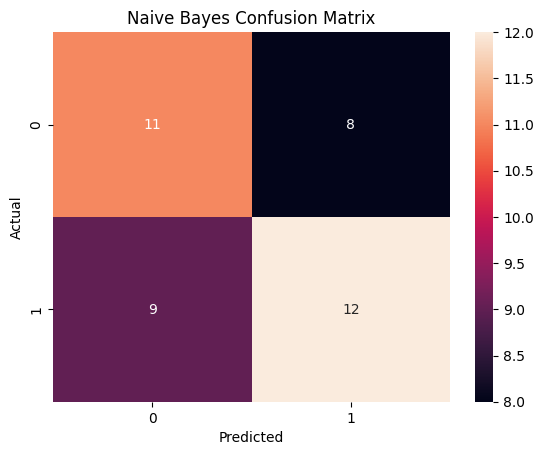

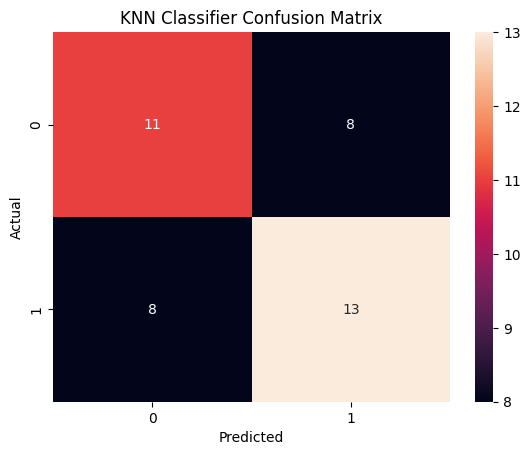

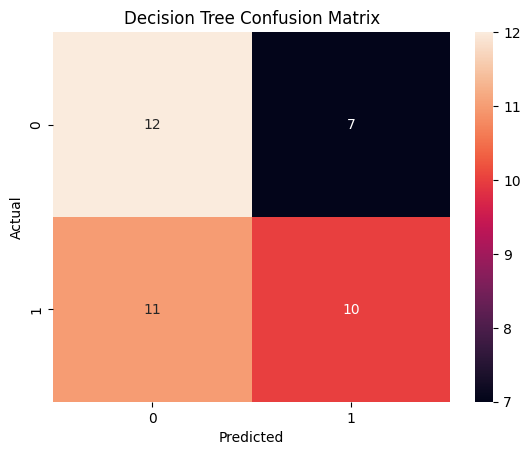

In [99]:
for model, y_pred in model_y_pred.items():
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')

    plt.title(f"{model} Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [100]:
model_var = {
    "Naive Bayes" : nb_model,
    'KNN Classifier' : knn_model,
    'Decision Tree' : dt_model
}

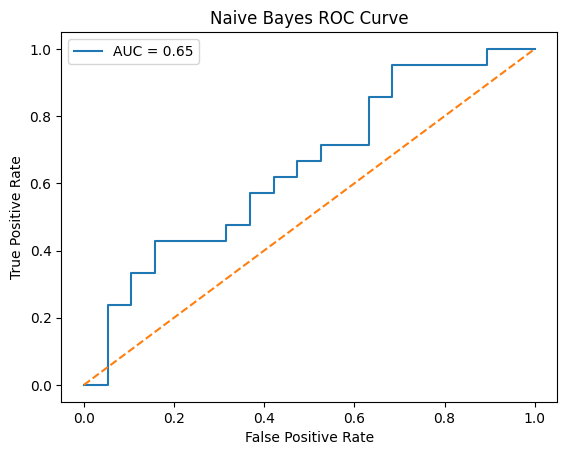

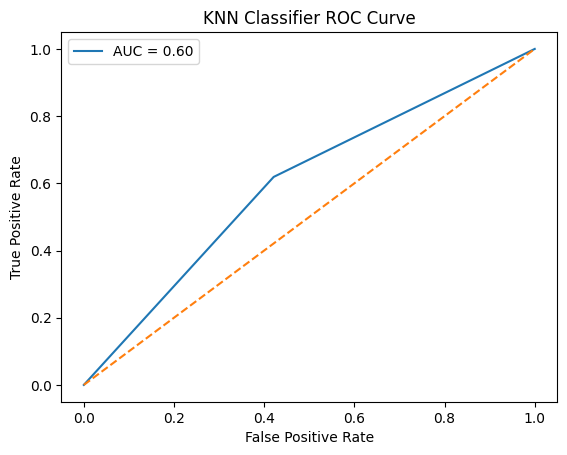

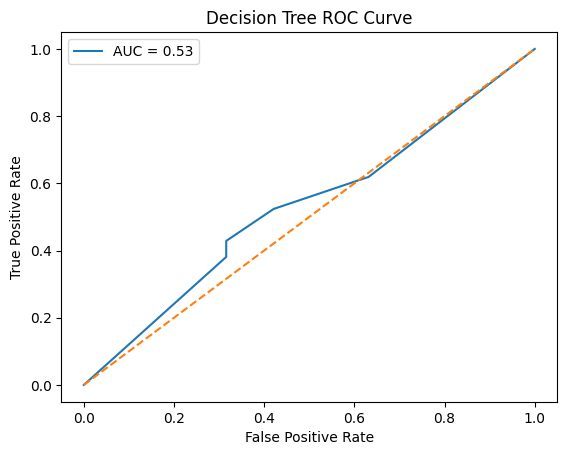

In [101]:
for model, var in model_var.items():
    y_prob = var.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{model} ROC Curve")

    plt.legend()

    plt.show()

## Final Conclusion

- **KNN** is the best-performing model on this dataset with the highest test accuracy: **0.60**.
- **Naive Bayes** follows with moderate accuracy: **0.575**.
- **Decision Tree** performed least well here with accuracy **0.55**.

Based on the current results, the **KNN model** is the recommended choice for predicting delivery status. However, continue validating with confusion matrix and ROC/AUC analysis before final deployment, and consider additional feature engineering or hyperparameter tuning if you need better performance.